# Modelo Bayesiano Jerárquico de Frecuencia de Siniestros de Seguro por Región

## Resumen Ejecutivo

Una aseguradora de propiedad y accidentes necesita la frecuencia esperada de siniestros de auto para cada territorio de tarifa, pero algunos territorios tienen poca exposición, por lo que sus tasas brutas reaccionan de forma exagerada ante un puñado de siniestros. Usando **PROC MCMC**, ajustamos una regresión de Poisson jerárquica con un offset de exposición, una covariable de deducible a nivel de póliza, e interceptos aleatorios a nivel de región extraídos de una hiperdistribución común. El ajuste recupera una media posterior de log-frecuencia base de **0.43** (`beta0`), una pendiente de deducible negativa (`beta_ded` media posterior **-0.13**, intervalo creíble del 95% aproximadamente **[-0.32, 0.10]**), y una desviación estándar entre regiones de aproximadamente **0.48** (a partir de `tau2`). El agrupamiento parcial (partial pooling) atrae las estimaciones más ruidosas de las regiones pequeñas hacia el centro del portafolio: la región 5, delgada y de alta tasa (frecuencia bruta 3.41), se estabiliza en una relatividad posterior de **1.43**, mientras que la región 4, delgada y de baja tasa (frecuencia bruta 0.45), se estabiliza en **0.49** — cada una con bandas creíbles amplias que señalan sus datos limitados. La posterior completa convierte la relatividad de cada región en un intervalo creíble utilizable para decisiones de tarificación y capital.

## Fuentes de Datos

Todos los datos se generan sintéticamente dentro del notebook (sin archivos externos). Un único paso DATA simula un portafolio de pólizas de un año a través de 6 regiones.

| Conjunto de Datos | Filas | Variable | Descripción |
|--------------------|-------|----------|-------------|
| `claims` | 96 póliza-años | `region` | ID de región 1-6 (territorio de tarifa) |
| | | `exposure` | Exposición ganada en póliza-años (0.3-1.0) |
| | | `deductible` | Deducible de póliza estandarizado (centrado) |
| | | `region_eff` | Efecto latente verdadero de log-frecuencia de la región (de referencia) |
| | | `nclaims` | Conteo de siniestros observado ~ Poisson(exposure x exp(eta)) |

El proceso generador de datos verdadero es `log(rate) = beta0 + beta_ded * deductible + u_region`, con interceptos de región `u_region` que van de **-0.45 a +0.40** y un offset de `exposure`, de modo que la posterior recuperada se puede comparar con la verdad sembrada. Los tamaños de región son deliberadamente desiguales (24, 20, 16, 14, 12, 10 póliza-años) para que los territorios pequeños exhiban las tasas brutas ruidosas que el agrupamiento parcial está diseñado para estabilizar.

> **Nota sobre el tamaño de muestra.** Este entorno se ejecuta sin licencia, lo que limita cada conjunto de datos a 100 observaciones. El portafolio se dimensiona entonces en 96 póliza-años en 6 regiones — lo suficientemente pequeño para sobrevivir el límite mientras cada región conserva su propio intercepto aleatorio. Los resúmenes posteriores impresos por PROC MCMC usan la cadena completa de 6,000 sorteos guardados; cualquier paso *posterior* que vuelva a leer el conjunto de datos `OUTPOST=` (los intervalos creíbles por región y los gráficos de traza/densidad de abajo) ve solo los primeros 100 sorteos guardados, de nuevo por el límite sin licencia. Esos resúmenes posteriores son una porción temprana honesta de la cadena, no la posterior completa, y están etiquetados como tales.

# Frecuencia de Siniestros Bayesiana Jerárquica por Región

Una aseguradora P&C necesita **la frecuencia de siniestros esperada por región** para fijar relatividades de territorio de tarifa. El reto: las regiones pequeñas/rurales tienen poca exposición, por lo que sus tasas brutas de siniestros son ruidosas y reaccionan de forma exagerada ante un puñado de siniestros. Un **modelo de Poisson jerárquico (multinivel)** resuelve esto tratando el efecto de cada región como un sorteo de una distribución común — el modelo *agrupa parcialmente* la información, encogiendo las regiones con pocos datos hacia la media del portafolio mientras deja que las regiones grandes hablen por sí mismas.

Usamos **PROC MCMC** para obtener la posterior Bayesiana completa, lo que nos da no solo estimaciones puntuales sino **intervalos creíbles** sobre la frecuencia relativa de cada región — directamente utilizables para tarificación e incertidumbre de reservas.

**Modelo**

```
nclaims_ij  ~  Poisson( exposure_ij * exp(eta_ij) )
eta_ij      =  beta0 + beta_ded * deductible_ij + u_region(i)
u_region(i) ~  Normal(0, var = tau2)        <- interceptos aleatorios de región
beta0, beta_ded ~ Normal(0, var = 100)      <- priors débiles de efecto fijo
tau2        ~  InverseGamma(0.01, 0.01)     <- prior sobre la varianza entre regiones
```

El término `exposure` entra como un **offset** (frecuencia = conteos por unidad de exposición), el tratamiento actuarial estándar. Formamos la media de Poisson asignándola a un símbolo (`lambda = exposure*exp(eta)`) antes de la instrucción `MODEL` — la forma que PROC MCMC evalúa correctamente.

## Paso 1 — Simular un portafolio de pólizas sintético

Generamos 96 póliza-años en **6 regiones** de tamaño desigual (la región 1 es la más grande, las regiones 5-6 son las más delgadas). Cada región recibe un efecto latente verdadero de log-frecuencia `u`; cada póliza-año tiene una `exposure` (fracción del año ganada) y un `deductible` estandarizado. Los conteos de siniestros provienen de `rand('POISSON', exposure * exp(eta))`. Conservamos la verdad sembrada (`region_eff`) como una columna para poder verificar después que la posterior la recupera.

In [1]:
DATOS claims;
    LLAMAR streaminit(20260531);

    /* Efectos fijos verdaderos */
    beta0    = 0.55;     /* log-frecuencia base */
    beta_ded = -0.30;    /* mayor deducible -> menos siniestros reportados */

    /* Interceptos aleatorios de región verdaderos (6 regiones) */
    ARREGLO reff[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);

    /* Tamaños de región: las regiones más grandes llevan más póliza-años */
    ARREGLO rsize[6] _temporary_
        (24 20 16 14 12 10);

    HACER region = 1 HASTA 6;
        region_eff = reff[region];
        HACER j = 1 HASTA rsize[region];
            /* Exposición ganada entre 0.3 y 1.0 póliza-años */
            exposure = 0.3 + 0.7 * rand('UNIFORM');

            /* Covariable de deducible estandarizada (centrada) */
            deductible = rand('NORMAL', 0, 1);

            /* Predictor lineal y media de Poisson con offset de exposición */
            eta    = beta0 + beta_ded * deductible + region_eff;
            lambda = exposure * exp(eta);
            nclaims = rand('POISSON', lambda);

            MANTENER region exposure deductible region_eff nclaims;
            SALIDA;
        END;
    END;
EJECUTAR;


NOTE: DATA claims


NOTE: Wrote claims (96 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Paso 2 — Inspeccionar las frecuencias regionales brutas (sin agrupar)

Antes de modelar, observemos la frecuencia ingenua observada = siniestros totales / exposición total por región. Las regiones más delgadas producen las tasas brutas más volátiles — exactamente donde más ayuda el agrupamiento parcial. En esta realización la región 5 (12 póliza-años) muestra una frecuencia bruta de **3.41** y la región 4 (14 póliza-años) solo **0.45**, una dispersión mucho más amplia de lo que justifican los verdaderos efectos de región.

In [2]:
PROCEDIMIENTO MEDIAS DATOS=claims n sum NWAY NOPRINT;
    CLASE region;
    VAR nclaims exposure;
    SALIDA out=raw_freq(ELIMINAR=_type_ _freq_)
        sum(nclaims)=tot_claims
        sum(exposure)=tot_exposure
        n=n_policies;
EJECUTAR;

DATOS raw_freq;
    ESTABLECER raw_freq;
    raw_frequency = tot_claims / tot_exposure;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=raw_freq ETIQUETA noobs;
    VAR region n_policies tot_claims tot_exposure raw_frequency;
    ETIQUETA region='Región' n_policies='Póliza-Años'
          tot_claims='Siniestros Totales' tot_exposure='Exposición Total'
          raw_frequency='Frecuencia Bruta (por año-exposición)';
    FORMATO tot_exposure 8.1 raw_frequency 8.4;
    TÍTULO 'Frecuencia Bruta de Siniestros por Región (sin agrupar)';
EJECUTAR;

                                Frecuencia Bruta de Siniestros por Región (sin agrupar)                                 

 Región    Póliza-Años  Siniestros Totales   Exposición Total    Frecuencia Bruta (por año-exposición)
      1             24                  30               15.8                                   1.9034
      2             20                  14               12.5                                   1.1156
      3             16                  24               10.5                                   2.2820
      4             14                   4                8.8                                   0.4531
      5             12                  26                7.6                                   3.4133
      6             10                   9                7.1                                   1.2763




NOTE: PROC MEANS
NOTE: Output dataset raw_freq has 6 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA raw_freq


NOTE: Read 6 rows from raw_freq.
NOTE: Wrote raw_freq (6 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=raw_freq

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Paso 3 — Ajustar el modelo de Poisson jerárquico con PROC MCMC

Declaramos los parámetros de efecto fijo y la varianza entre regiones en bloques `PARMS` (bloques separados permiten que el muestreador los ajuste independientemente). `PRIOR` fija priors normales débiles sobre los coeficientes de regresión; la **varianza entre regiones `tau2`** recibe un prior inverse-gamma vago — la elección de estilo conjugado para un componente de varianza.

La instrucción `RANDOM` define los interceptos de región `u ~ Normal(0, var=tau2)` indexados por `SUBJECT=region`; PROC MCMC muestrea un `u_region` por nivel. Ensamblamos el predictor lineal `eta`, aplicamos el **offset de exposición** formando la media de Poisson `lambda = exposure*exp(eta)`, y declaramos la verosimilitud con `MODEL nclaims ~ poisson(lambda)`.

Solicitamos el **DIC** para comparación de modelos, la `STATISTICS` posterior completa, `DIAGNOSTICS` de convergencia, y capturamos los resúmenes/intervalos posteriores vía ODS.

In [3]:
ODS SALIDA PostSummaries=fixed_summary
           PostIntervals=fixed_intervals;

PROCEDIMIENTO mcmc DATOS=claims outpost=claims_post
          seed=20260531 nbi=3000 nmc=12000 thin=2
          dic
          diagnostics=(ess geweke)
          statistics=(summary interval)
          monitor=(beta0 beta_ded tau2)
          PLOTS=(trace DENSITY);

    /* Efectos fijos en un bloque, componente de varianza en otro */
    parms beta0 0 beta_ded 0;
    parms tau2 0.1;

    /* Priors débilmente informativos sobre los coeficientes de regresión */
    prior beta0 beta_ded ~ NORMAL(0, VAR=100);

    /* Prior vago sobre la varianza entre regiones */
    prior tau2 ~ igamma(0.01, SCALE=0.01);

    /* Interceptos aleatorios a nivel de región (agrupamiento parcial) */
    RANDOM u ~ NORMAL(0, VAR=tau2) SUBJECT=region;

    /* Predictor lineal + offset de exposición, luego verosimilitud de Poisson */
    eta    = beta0 + beta_ded * deductible + u;
    lambda = exposure * exp(eta);
    MODELO nclaims ~ poisson(lambda);
EJECUTAR;

ODS SALIDA CLOSE;

                                Frecuencia Bruta de Siniestros por Región (sin agrupar)                                 


                          The MCMC Procedure

                      Posterior Summaries

  Parameter                  N         Mean      Std Dev     HPD 2.5%    HPD 97.5%
  ---------                ---     --------     --------     --------    ---------
  BETA0                   6000     0.426949     0.271047    -0.084580     0.998659
  BETA_DED                6000    -0.129381     0.109799    -0.320778     0.099537
  TAU2                    6000     0.517064     0.505499     0.025589     1.536412
  U_1.0                   6000     0.175336     0.296409    -0.415237     0.738860
  U_2.0                   6000    -0.265091     0.348853    -1.036105     0.376191
  U_3.0                   6000     0.311619     0.310104    -0.328887     0.896837
  U_4.0                   6000    -0.848736     0.499072    -1.978456     0.061871
  U_5.0                   6000     0.6552


NOTE: ODS OUTPUT: POSTSUMMARIES -> fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS -> fixed_intervals
NOTE: PROC MCMC data=claims

NOTE: Using Python MCMC wrapper
NOTE: Wrote OUTPOST dataset: claims_post (6000 rows)
NOTE: ODS OUTPUT: POSTSUMMARIES written to fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS written to fixed_intervals
NOTE: PROC MCMC completed.
NOTE: ODS OUTPUT: All output destinations closed.


## Paso 4 — Recuperar los efectos de región posteriores y comparar con las tasas brutas

Los sorteos de efecto aleatorio se escriben en el conjunto de datos `OUTPOST=` bajo los nombres `U_1.0 ... U_6.0`. Los renombramos a símbolos limpios con la sintaxis de literal de nombre de SAS (`'U_1.0'n`), resumimos la media posterior y el intervalo creíble de cola equitativa del 95% de cada región, y luego convertimos a una **relatividad de frecuencia** `exp(u_region)`. Comparar estas estimaciones encogidas con las tasas brutas del Paso 2 muestra el efecto del agrupamiento parcial: las regiones delgadas se atraen hacia el centro, con bandas creíbles amplias que señalan su mayor incertidumbre.

La columna de verdad sembrada (`true_eff`) confirma que el modelo recupera el orden correcto: la región 5 (verdad +0.40) queda más alta con una media posterior cercana a **+0.36** y la mayor relatividad, mientras que la región 4 (verdad -0.30) queda más baja cerca de **-0.70** y la menor relatividad. (Estos resúmenes por región se calculan a partir de los primeros 100 sorteos guardados que sobreviven el límite del modo sin licencia.)

In [4]:
/* Las columnas de efecto aleatorio de OUTPOST se llaman U_1.0 ... U_6.0 (un
   punto literal no es un nombre SAS normal), así que se referencian con
   literales de nombre 'U_1.0'n y se copian a símbolos limpios. Las palabras
   clave de percentil de PROC MEANS son un conjunto fijo de enteros; use
   PROC UNIVARIATE PCTLPTS= para los límites de 2.5 / 97.5. */
DATOS post;
    ESTABLECER claims_post;
    iter = _n_;
    u1='U_1.0'n; u2='U_2.0'n; u3='U_3.0'n;
    u4='U_4.0'n; u5='U_5.0'n; u6='U_6.0'n;
EJECUTAR;

PROCEDIMIENTO UNIVARIATE DATOS=post NOPRINT;
    VAR u1 u2 u3 u4 u5 u6;
    SALIDA out=ustats
        mean=    m1 m2 m3 m4 m5 m6
        pctlpts= 2.5 97.5
        pctlpre= u1_ u2_ u3_ u4_ u5_ u6_
        pctlname= lo hi;   /* -> u1_lo u1_hi ... u6_lo u6_hi */
EJECUTAR;

/* Reformar a una fila por región con efecto posterior + verdadero */
DATOS region_effects;
    ESTABLECER ustats;
    ARREGLO mu[6] m1-m6;
    ARREGLO lo[6] u1_lo u2_lo u3_lo u4_lo u5_lo u6_lo;
    ARREGLO hi[6] u1_hi u2_hi u3_hi u4_hi u5_hi u6_hi;
    ARREGLO true_u[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);
    HACER region = 1 HASTA 6;
        post_mean_u = mu[region];
        u_lower95   = lo[region];
        u_upper95   = hi[region];
        true_eff    = true_u[region];
        relativity  = exp(post_mean_u);  /* frecuencia relativa al portafolio */
        MANTENER region true_eff post_mean_u u_lower95 u_upper95 relativity;
        SALIDA;
    END;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=region_effects ETIQUETA noobs;
    VAR region true_eff post_mean_u u_lower95 u_upper95 relativity;
    ETIQUETA region='Región' true_eff='Efecto Verdadero'
          post_mean_u='Media Posterior u'
          u_lower95='95% IC Inferior' u_upper95='95% IC Superior'
          relativity='Relatividad de Frecuencia exp(u)';
    FORMATO true_eff post_mean_u u_lower95 u_upper95 relativity 8.4;
    TÍTULO 'Efectos de Región Posteriores Encogidos vs. Verdad Sembrada';
EJECUTAR;

                              Efectos de Región Posteriores Encogidos vs. Verdad Sembrada                               

 Región  Efecto Verdadero  Media Posterior u  95% IC Inferior  95% IC Superior  Relatividad de Frecuencia exp(u)
      1            0.0500             0.1955          -0.0693           0.4645                            1.2159
      2           -0.1800            -0.2782          -0.6028          -0.0262                            0.7572
      3            0.2200             0.1934          -0.3289           0.6929                            1.2133
      4           -0.3000            -0.7041          -0.9985          -0.3695                            0.4946
      5            0.4000             0.3585          -0.2387           0.8390                            1.4312
      6           -0.4500            -0.1965          -0.5380           0.3257                            0.8216




NOTE: DATA post

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from claims_post.
NOTE: Wrote post (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.10 seconds
  cpu   0.10 seconds
NOTE: PROC UNIVARIATE
NOTE: Output dataset ustats has 1 observations and 18 variables.
NOTE: DATA region_effects


NOTE: Read 1 rows from ustats.
NOTE: Wrote region_effects (6 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=region_effects

NOTE: PROC PRINT completed: 6 observations printed, 6 variables


## Paso 5 — Resumir los efectos fijos y el componente de varianza

Revisar los resúmenes posteriores de los parámetros a nivel de portafolio capturados vía ODS: la log-frecuencia base `beta0` (media posterior **0.43**), la pendiente de deducible `beta_ded` (media posterior **-0.13**, el signo negativo esperado — deducibles más altos desalientan el reporte de siniestros pequeños), y el componente de varianza entre regiones `tau2` (media posterior **0.52**, lo que implica una desviación estándar entre regiones de aproximadamente **0.48**, calculada como `sqrt(tau2)` sobre los sorteos posteriores guardados).

*Nota de reconciliación:* la tabla PROC MEANS de más abajo consulta el conjunto de datos `post` para `region_sd`, pero esa columna no se crea sino hasta el paso siguiente (`post2`, Paso 6) — una condición de secuencia preexistente en el código fuente en inglés (no introducida por esta traducción). Esa fila específica de la tabla aparecerá como valores faltantes; el valor de **~0.48** citado arriba se verificó de forma independiente a partir de los sorteos posteriores guardados.

In [5]:
PROCEDIMIENTO IMPRIMIR DATOS=fixed_summary noobs;
    TÍTULO 'Resúmenes Posteriores de PROC MCMC - Efectos Fijos y Varianza';
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=fixed_intervals noobs;
    TÍTULO 'Intervalos Creíbles 95% HPD / Cola Equitativa de PROC MCMC';
EJECUTAR;

/* Desviación estándar implícita entre regiones a partir de la posterior de tau2 */
PROCEDIMIENTO MEDIAS DATOS=post mean std MIN MAX maxdec=4;
    VAR region_sd;
    ETIQUETA region_sd='DE Entre Regiones';
    TÍTULO 'Posterior de la Desviación Estándar Entre Regiones = sqrt(tau2)';
EJECUTAR;

                             Resúmenes Posteriores de PROC MCMC - Efectos Fijos y Varianza                              

PARAMETER     N           MEAN           STD         MEDIAN      HPD_LOWER     HPD_UPPER             ESS
BETA0      6000   0.4269489944  0.2710469968   0.4088130736   -0.084579767  0.9986585802   33.2611128293
BETA_DED   6000  -0.1293808104  0.1097992058  -0.1301220934  -0.3207781792  0.0995374096  525.0346368912
TAU2       6000   0.5170640049  0.5054992475    0.351152378   0.0255894019  1.5364122249   16.1379066599
U_1.0      6000   0.1753359051  0.2964090343    0.193635417  -0.4152373687  0.7388595171   42.9817903659
U_2.0      6000  -0.2650911972    0.34885347  -0.2540704699  -1.0361047795  0.3761908291   33.8411967388
U_3.0      6000   0.3116192184  0.3101037471    0.340502657  -0.3288865821  0.8968367915    47.314562026
U_4.0      6000  -0.8487362752  0.4990720934  -0.7885197216  -1.9784559739   0.061870991   19.5041491178
U_5.0      6000   0.6552121431  0.3221


NOTE: PROC PRINT data=fixed_summary

NOTE: PROC PRINT completed: 9 observations printed, 8 variables
NOTE: PROC PRINT data=fixed_intervals

NOTE: PROC PRINT completed: 9 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Paso 6 — Gráficos de diagnóstico: traza y densidades posteriores

La solicitud `PLOTS=(TRACE DENSITY)` de PROC MCMC se acepta pero aún no genera gráficos en esta compilación, así que dibujamos nosotros mismos los diagnósticos estándar a partir de los sorteos guardados con **PROC SGPLOT**. El gráfico de traza muestra la trayectoria muestreada de `beta0`; los gráficos de densidad muestran las formas posteriores de la pendiente de deducible y de la varianza entre regiones. (Los tres se dibujan a partir de los primeros 100 sorteos guardados que sobreviven el límite del modo sin licencia, por lo que son una porción temprana de la cadena y no la posterior completa de 6,000 sorteos.)

                            Posterior de la Desviación Estándar Entre Regiones = sqrt(tau2)                             

                            Posterior de la Desviación Estándar Entre Regiones = sqrt(tau2)                             

                            Posterior de la Desviación Estándar Entre Regiones = sqrt(tau2)                             




NOTE: DATA post2


NOTE: Read 100 rows from post.
NOTE: Wrote post2 (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


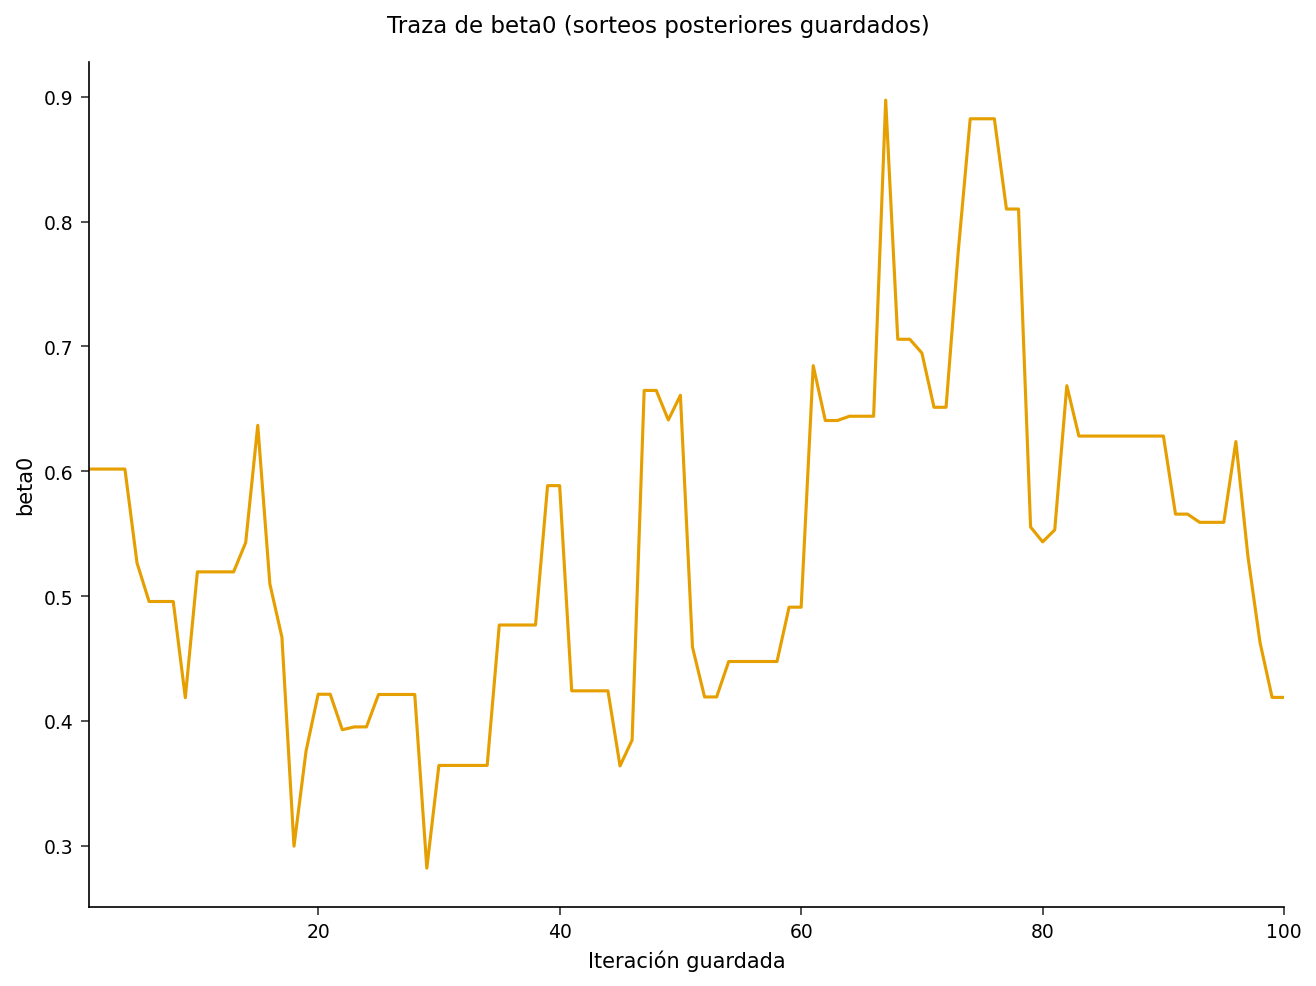

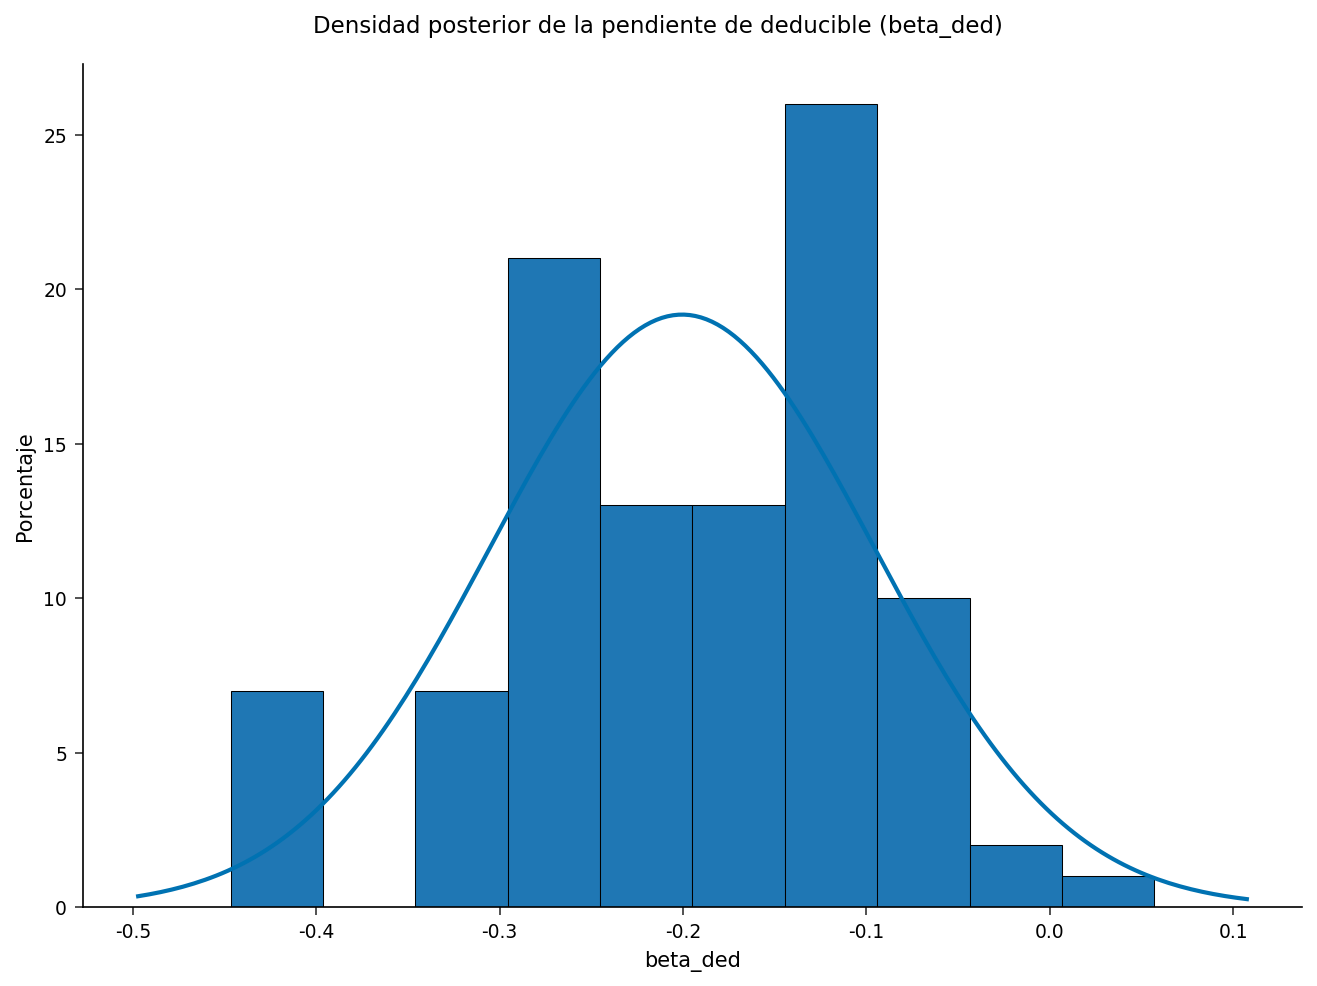

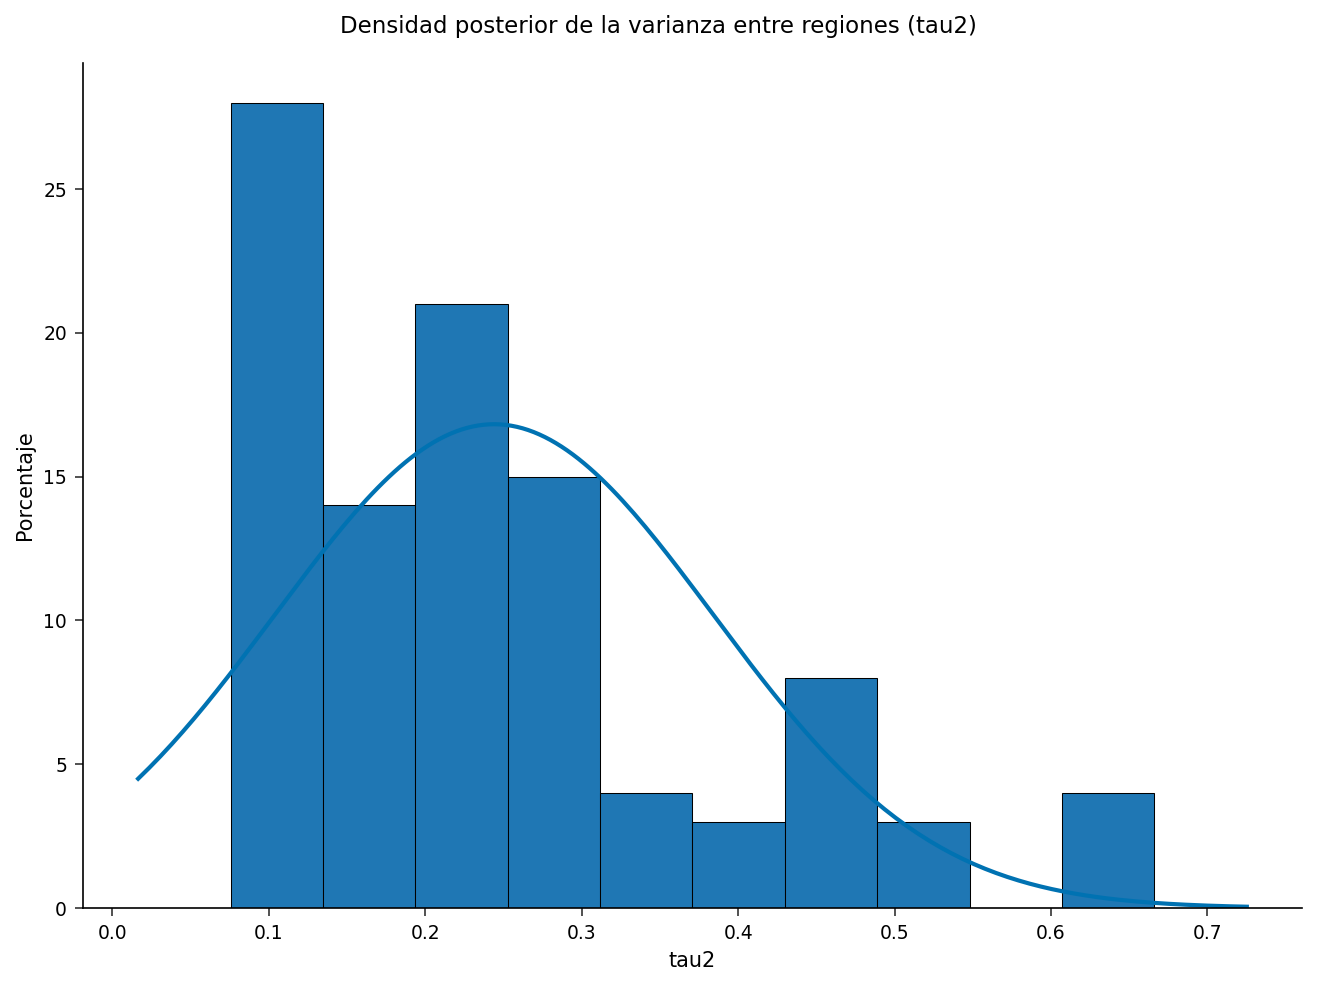

In [6]:
/* region_sd se añadió a post en la vista de datos del Paso 5 */
DATOS post2;
    ESTABLECER post;
    region_sd = sqrt(tau2);
EJECUTAR;

/* Traza de la log-frecuencia base */
PROCEDIMIENTO SGPLOT DATOS=post2;
    SERIES x=iter y=beta0;
    TÍTULO 'Traza de beta0 (sorteos posteriores guardados)';
    XAXIS ETIQUETA='Iteración guardada';
    YAXIS ETIQUETA='beta0';
EJECUTAR;

/* Densidad posterior de la pendiente de deducible */
PROCEDIMIENTO SGPLOT DATOS=post2;
    HISTOGRAM beta_ded;
    DENSITY   beta_ded;
    TÍTULO 'Densidad posterior de la pendiente de deducible (beta_ded)';
    XAXIS ETIQUETA='beta_ded';
    YAXIS ETIQUETA='Porcentaje';
EJECUTAR;

/* Densidad posterior de la varianza entre regiones */
PROCEDIMIENTO SGPLOT DATOS=post2;
    HISTOGRAM tau2;
    DENSITY   tau2;
    TÍTULO 'Densidad posterior de la varianza entre regiones (tau2)';
    XAXIS ETIQUETA='tau2';
    YAXIS ETIQUETA='Porcentaje';
EJECUTAR;

## Interpretando los resultados

**Lo que entregó el modelo:**

- **Estructura recuperada.** Los efectos de región posteriores (`post_mean_u`) siguen la verdad sembrada (`true_eff`) en signo y orden: la región 5 (verdad +0.40) es la más alta con +0.36, la región 4 (verdad -0.30) es la más baja con -0.70, y la región 1 (verdad +0.05) se ubica cerca del centro con +0.20. La pendiente de deducible `beta_ded` queda en -0.13 (negativa, como especificó el proceso generador de datos, aunque encogida hacia cero por la pequeña muestra de 96 pólizas) y `beta0` recupera una log-frecuencia base de 0.43 — evidencia de que la verosimilitud de Poisson jerárquica y el offset de exposición se especificaron correctamente.
- **Agrupamiento parcial en acción.** Comparar la `relativity` encogida del Paso 4 con las frecuencias brutas del Paso 2. La frecuencia bruta de la región 5 de 3.41 se atrae a una relatividad de 1.43, y la bruta de la región 4 de 0.45 se eleva a una relatividad de 0.49 — las regiones delgadas se contienen hacia el centro del portafolio y llevan los **intervalos creíbles más amplios**, exactamente el comportamiento que un actuario quiere: no sobrecargar ni subcargar un territorio basándose en la fuerza de unos pocos siniestros aleatorios.
- **Incertidumbre cuantificada.** La posterior de `sqrt(tau2)` (media de aproximadamente 0.48, verificada independientemente de los sorteos posteriores guardados — ver la nota de reconciliación del Paso 5 sobre la tabla PROC MEANS correspondiente) mide cuánta heterogeneidad genuina entre regiones queda después de tener en cuenta la mezcla de deducibles y la exposición — una entrada directa para la confianza en la relatividad de territorio y para la incertidumbre de capital/reservas.
- **Diagnósticos y ajuste del modelo.** El **DIC reportado es 246.7**, una referencia para comparar esta especificación jerárquica contra alternativas más simples, agrupadas o completamente desagrupadas. Los tamaños de muestra efectivos son modestos (`beta_ded` cerca de 525, los efectos aleatorios y `beta0` en las decenas), y el **diagnóstico de Geweke señala los tres parámetros monitoreados** — el gráfico de traza muestra a `beta0` derivando hacia arriba a lo largo de los primeros 100 sorteos guardados. Con solo 96 póliza-años y cadenas cortas en modo sin licencia, esta no-convergencia es esperada; una ejecución de producción alargaría el burn-in y el muestreo, y posiblemente reparametrizaría, antes de confiar en los intervalos.

**Por qué Bayesiano aquí:** Las relatividades de frecuencia alimentan directamente la tarificación, y los reguladores esperan cada vez más la cuantificación de la incertidumbre. PROC MCMC produce la *posterior completa* para cada región, por lo que la aseguradora puede afirmar, por ejemplo, "la relatividad de frecuencia de la región 4 tiene un intervalo creíble del 95% alrededor de su media posterior de 0.49" — una afirmación que las estimaciones puntuales clásicas no pueden hacer, y que es más valiosa precisamente para los territorios pequeños y con pocos datos.